In [11]:
import SOAP
from SOAP import PHOENIX
import matplotlib.pyplot as plt
import numpy as np
from ldtk import LDPSetCreator, BoxcarFilter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from create_spectrum_SOAP import create_spectrum_soap, create_spectrum_phoenix


In [12]:
# Stellar properties

teff = 5778
teff_sig = 10
logg = 4.44
logg_sig = 0.001
feh = 0.00
feh_sig = 0.01
wave_min = 3800.0
wave_max = 7800.0
wave_range = (wave_min, wave_max)
wavelength_mode = "vacuum"
R = 115000
prot = 25.67
radius = 1.0
mass = 1.0
psi = [0]



In [13]:
spec_phoenix, wave_phoenix, flux_phoenix = create_spectrum_phoenix(
    teff=teff,
    logg=logg,
    z=feh,
    wave_min=wave_min,
    wave_max=wave_max,
    wavelength_mode="vacuum",  # or "air"
    r=R,                  # or None
    normalize_max = True
)


In [14]:
soap_result = create_spectrum_soap(
    teff=teff,
    logg=logg,
    z=feh,
    wave_min=wave_min,
    wave_max=wave_max,
    wavelength_mode="vacuum",
    r=R ,
    prot=prot,
    radius=radius,
    mass=mass,
    teff_sig=teff_sig,
    logg_sig=logg_sig,
    z_sig=feh_sig,
    psi=psi,
)

In [15]:
wave_soap = soap_result.wave
flux_soap = soap_result.flux
ccf_flux_soap = soap_result.ccf_flux
rv_ccf_soap = soap_result.rv_ccf

sim_soap = soap_result.sim
output_soap = soap_result.output
spectrum_soap = soap_result.input_spectrum


In [25]:
downsample_flux = flux_phoenix.copy()
downsample_wave = wave_phoenix.copy()

# Downsample it to make computations faster (this can be adjusted as needed)
downsample_flux=downsample_flux[::3]
downsample_wave=downsample_wave[::3]

In [18]:
#plt.scatter(sim.rv, sim.ccf[0]/sim.ccf[0].max(), label='SOAP CCF')

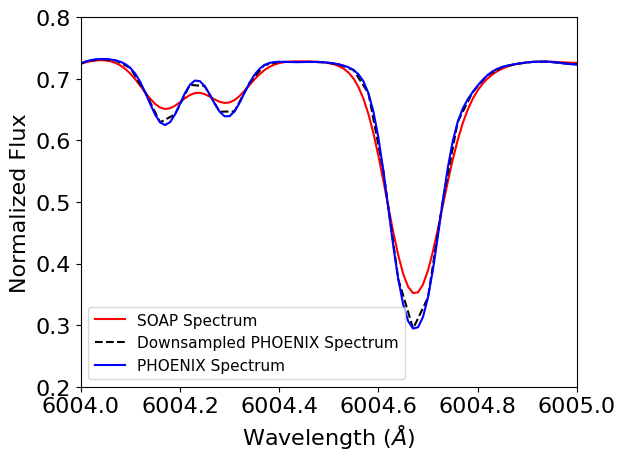

In [23]:
plt.plot(wave_soap, flux_soap[0], 'r', label='SOAP Spectrum')
plt.plot(downsample_wave, downsample_flux, 'k--', label='Downsampled PHOENIX Spectrum')
plt.plot(wave_phoenix, flux_phoenix, 'b-', label='PHOENIX Spectrum')
#plt.xlim(5903.6, 5904.3); plt.ylim(0.3,0.8)
plt.ylim(0.2,0.8); plt.xlim(6004., 6005)
plt.xlabel("Wavelength ("+r"$\AA$"+")")
plt.ylabel("Normalized Flux");
plt.legend(fontsize = 11)

### Do not downlample!